### 1. Data Loading and Initial Characterisation
In this section, we load the dataset and perform a high-level overview of its structure.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
try:
    df = pd.read_csv('/content/social_media_posts.csv')
    print("Dataset loaded successfully.")
    display(df.head())
    display(df.info())
except FileNotFoundError:
    print("Error: 'social_media_posts.csv' not found. Please ensure the file is uploaded to the runtime.")

Dataset loaded successfully.


,PostID,Category,PostingTime,Likes,Shares,Comments
0,1,Tech,2026-01-01 10:15,120,15,30
1,2,Food,2026-01-01 18:45,200,25,40
2,3,Fashion,2026-01-02 12:30,150,20,35
3,4,Tech,2026-01-02 09:00,90,10,20
4,5,Food,2026-01-02 20:10,250,30,50


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   PostID       50 non-null     int64 
 1   Category     50 non-null     object
 2   PostingTime  50 non-null     object
 3   Likes        50 non-null     int64 
 4   Shares       50 non-null     int64 
 5   Comments     50 non-null     int64 
dtypes: int64(4), object(2)
memory usage: 2.5+ KB


None

### 2. Class Distribution Analysis
We need to check if the dataset is balanced or imbalanced, as this significantly impacts model training and evaluation metric selection.

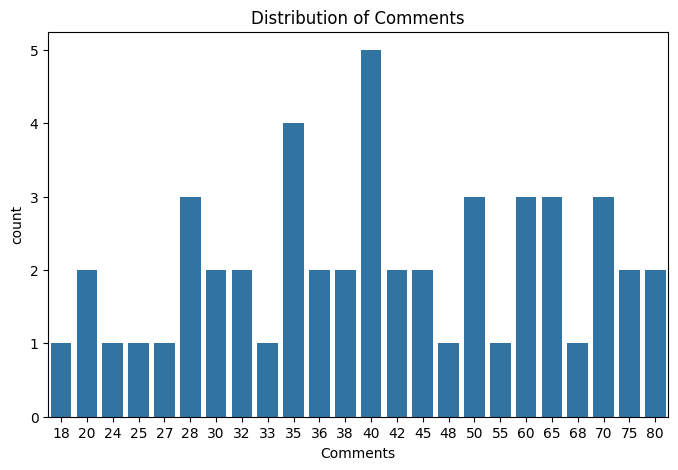

Class Proportions:
Comments
40    0.10
35    0.08
28    0.06
50    0.06
60    0.06
70    0.06
65    0.06
30    0.04
38    0.04
20    0.04
42    0.04
45    0.04
36    0.04
80    0.04
75    0.04
32    0.04
18    0.02
25    0.02
55    0.02
48    0.02
33    0.02
27    0.02
68    0.02
24    0.02
Name: proportion, dtype: float64


In [5]:
# Assuming 'sentiment' or 'category' is the target class. Let's inspect unique counts.
# Replace 'target_column' with the actual column name after seeing df.info()
target_col = df.columns[-1] # Usually the last column if not specified

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=target_col)
plt.title(f'Distribution of {target_col}')
plt.show()

print("Class Proportions:")
print(df[target_col].value_counts(normalize=True))

### 3. Language and Engagement Columns
Characterising the language and engagement metrics to understand data quality and feature relevance.

,Likes,Shares,Comments
count,50.000000,50.000000,50.000000
mean,198.100000,25.100000,45.060000
std,73.539452,9.875242,17.177833
min,90.000000,8.000000,18.000000
25%,142.500000,18.000000,32.250000
50%,177.500000,23.000000,40.000000
75%,277.500000,34.250000,60.000000
max,330.000000,45.000000,80.000000


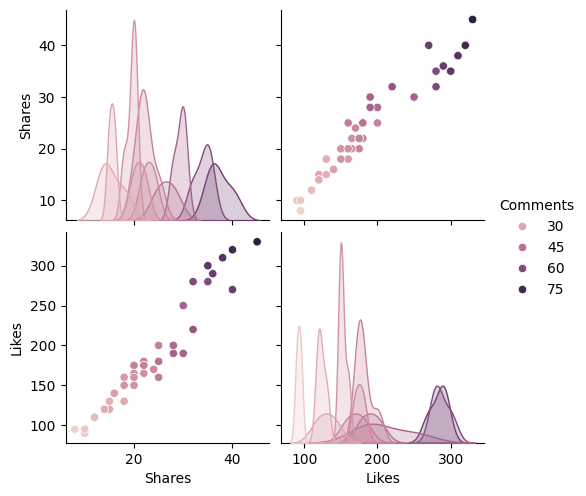

In [7]:
# Language distribution
if 'language' in df.columns:
    print("Language Distribution:")
    display(df['language'].value_counts())

# Engagement analysis (e.g., likes, shares, comments)
# Filter engagement columns and ensure target_col is removed from the feature set to avoid duplication errors
engagement_cols = [col for col in df.columns if any(x in col.lower() for x in ['like', 'share', 'comment', 'engagement'])]

if engagement_cols:
    display(df[engagement_cols].describe())

    # Fix: Create a list of unique columns for plotting to avoid 'Data must be 1-dimensional' error
    plot_cols = list(set(engagement_cols + [target_col]))

    sns.pairplot(df[plot_cols], hue=target_col)
    plt.show()